In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

INCLUDE_NO_NORM = True

model_name_to_show_label = {
    "CausalRevIN_True": r"Causal + $\sinh^{-1}$",
    "CausalRevIN_False": "Causal",
    "RevIN_True": r"RevIN + $\sinh^{-1}$",
    "RevIN_False": "RevIN",
    "PrefixRevIN_True": r"Prefix@k + $\sinh^{-1}$",
    "PrefixRevIN_False": "Prefix@k", 
    "NoRevIN_False": "NoNorm"

}

dic_model_colors = {
    r"Causal + $\sinh^{-1}$": "#FF7F00",  # vivid orange
    r"Causal":                 "#573030FF",  # semi-transparent brown
    r"RevIN + $\sinh^{-1}$":   "#00CC66",  # vivid green
    r"RevIN":                  "#0055FF",  # electric deep blue
    r"Prefix@k + $\sinh^{-1}$": "#FF3300",  # bright red-orange
    r"Prefix@k":               "#CC0099",  # strong magenta
    "NoNorm":                "#999999",  # medium gray

}

def load_npz(filepath):
    """Load npz file and return as dictionary"""
    return np.load(filepath)

models = ["CausalRevIN_True", "CausalRevIN_False", "PrefixRevIN_True", 
          "PrefixRevIN_False", "RevIN_True", "RevIN_False"]

if INCLUDE_NO_NORM:
    models.append("NoRevIN_False")

context_lengths = ["128", "256", "512"]
datasets = ["utsd", "gift_eval", "artificial"]

aggregated_skill_scores = {
    'mse': np.zeros((len(models), len(models))),
    'mae': np.zeros((len(models), len(models))),
    'mase': np.zeros((len(models), len(models))),
    'sql': np.zeros((len(models), len(models)))
}

skill_scores_mse_matrix = np.zeros((len(models), len(models)))
skill_scores_mae_matrix = np.zeros((len(models), len(models)))
skill_scores_mase_matrix = np.zeros((len(models), len(models)))
skill_scores_sql_matrix = np.zeros((len(models), len(models)))

for i, baseline in enumerate(models):
    for j, comparison in enumerate(models):
        mse_baseline = []
        mae_baseline = []
        mase_baseline = []
        sql_baseline = []
        mse_comparison = []
        mae_comparison = []
        mase_comparison = []
        sql_comparison = []
        
        for dataset in datasets:
            for context in context_lengths:
                try:
                    r_baseline = load_npz(f'../processed_results/{baseline}/{context}/results_{dataset}.npz')
                    r_comparison = load_npz(f'../processed_results/{comparison}/{context}/results_{dataset}.npz')
                    
                    for k1, k2 in zip(r_baseline, r_comparison):
                        assert k1 == k2, "Predictions do not match"
                        metric = k1.split("_")[0].lower()
                        
                        if metric == "rmse":
                            #mse_baseline.extend(r_baseline[k1])
                            #mse_comparison.extend(r_comparison[k2])
                            mse_baseline.append(np.mean(r_baseline[k1]))
                            mse_comparison.append(np.mean(r_comparison[k2]))
                        elif metric == "mae":
                            #mae_baseline.extend(r_baseline[k1])
                            #mae_comparison.extend(r_comparison[k2])
                            mae_baseline.append(np.mean(r_baseline[k1]))
                            mae_comparison.append(np.mean(r_comparison[k2]))
                        elif metric == "sql":
                            sql_baseline.append(np.mean(r_baseline[k1]))
                            sql_comparison.append(np.mean(r_comparison[k2]))
                        else:
                            #mase_baseline.extend(r_baseline[k1])
                            #mase_comparison.extend(r_comparison[k2])
                            mase_baseline.append(np.mean(r_baseline[k1]))
                            mase_comparison.append(np.mean(r_comparison[k2]))
                except FileNotFoundError:
                    print(f"Warning: Files not found for {baseline} or {comparison} on {dataset}")
                    continue
        
        if len(mse_baseline) > 0 and len(mse_comparison) > 0:
            scores_mse = []
            for p1, p2 in zip(mse_baseline, mse_comparison):
                scores_mse.append(p2/p1)
            scores_mse = np.array(scores_mse)
            scores_mse = np.clip(scores_mse, 0.01, 100)
            n = len(scores_mse)
            geometric_mean = np.exp(np.mean(np.log(scores_mse)))
            skill_scores_mse = 1 - geometric_mean
            skill_scores_mse_matrix[i, j] = skill_scores_mse
        
        # Calculate MAE skill score
        if len(mae_baseline) > 0 and len(mae_comparison) > 0:
            scores_mae = []
            for p1, p2 in zip(mae_baseline, mae_comparison):
                scores_mae.append(p2/p1)
            scores_mae = np.array(scores_mae)
            scores_mae = np.clip(scores_mae, 0.01, 100)
            n = len(scores_mae)
            geometric_mean = np.exp(np.mean(np.log(scores_mae)))
            skill_scores_mae = 1 - geometric_mean
            skill_scores_mae_matrix[i, j] = skill_scores_mae
        
        # Calculate MASE skill score
        if len(mase_baseline) > 0 and len(mase_comparison) > 0:
            scores_mase = []
            for p1, p2 in zip(mase_baseline, mase_comparison):
                scores_mase.append(p2/p1)
            scores_mase = np.array(scores_mase)
            scores_mase = np.clip(scores_mase, 0.01, 100)
            n = len(scores_mase)
            geometric_mean = np.exp(np.mean(np.log(scores_mase)))
            skill_scores_mase = 1 - geometric_mean
            skill_scores_mase_matrix[i, j] = skill_scores_mase
        
        # Calculate SQL skill score
        if len(sql_baseline) > 0 and len(sql_comparison) > 0:
            scores_sql = []
            for p1, p2 in zip(sql_baseline, sql_comparison):
                scores_sql.append(p2/p1)
            scores_sql = np.array(scores_sql)
            scores_sql = np.clip(scores_sql, 0.01, 100)
            n = len(scores_sql)
            geometric_mean = np.exp(np.mean(np.log(scores_sql)))
            skill_scores_sql = 1 - geometric_mean
            skill_scores_sql_matrix[i, j] = skill_scores_sql

        print(f"{baseline} vs {comparison} - RMSE: {skill_scores_mse_matrix[i,j]:.4f}, "
              f"MAE: {skill_scores_mae_matrix[i,j]:.4f}, MASE: {skill_scores_mase_matrix[i,j]:.4f}, SQL: {skill_scores_sql_matrix[i,j]:.4f}")

aggregated_skill_scores['mse'] = skill_scores_mse_matrix.T
aggregated_skill_scores['mae'] = skill_scores_mae_matrix.T
aggregated_skill_scores['mase'] = skill_scores_mase_matrix.T
aggregated_skill_scores['sql'] = skill_scores_sql_matrix.T

print("\n" + "="*50)
print("Aggregated skill scores across all context lengths")
print("="*50)

CausalRevIN_True vs CausalRevIN_True - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000, SQL: 0.0000
CausalRevIN_True vs CausalRevIN_False - RMSE: -0.1255, MAE: -0.1443, MASE: -0.0650, SQL: -0.0566
CausalRevIN_True vs PrefixRevIN_True - RMSE: -0.7417, MAE: -0.8011, MASE: -0.2704, SQL: -0.2654
CausalRevIN_True vs PrefixRevIN_False - RMSE: -0.2410, MAE: -0.2507, MASE: -0.0648, SQL: -0.0772
CausalRevIN_True vs RevIN_True - RMSE: -1.0018, MAE: -1.0413, MASE: -0.6097, SQL: -0.6615
CausalRevIN_True vs RevIN_False - RMSE: -1.0047, MAE: -1.0469, MASE: -0.6211, SQL: -0.6688
CausalRevIN_True vs NoRevIN_False - RMSE: -3.3943, MAE: -3.8735, MASE: -5.2617, SQL: -5.2060
CausalRevIN_False vs CausalRevIN_True - RMSE: 0.1115, MAE: 0.1261, MASE: 0.0610, SQL: 0.0536
CausalRevIN_False vs CausalRevIN_False - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000, SQL: 0.0000
CausalRevIN_False vs PrefixRevIN_True - RMSE: -0.5475, MAE: -0.5739, MASE: -0.1929, SQL: -0.1976
CausalRevIN_False vs PrefixRevIN_False - RMSE: -0.1026, MAE:

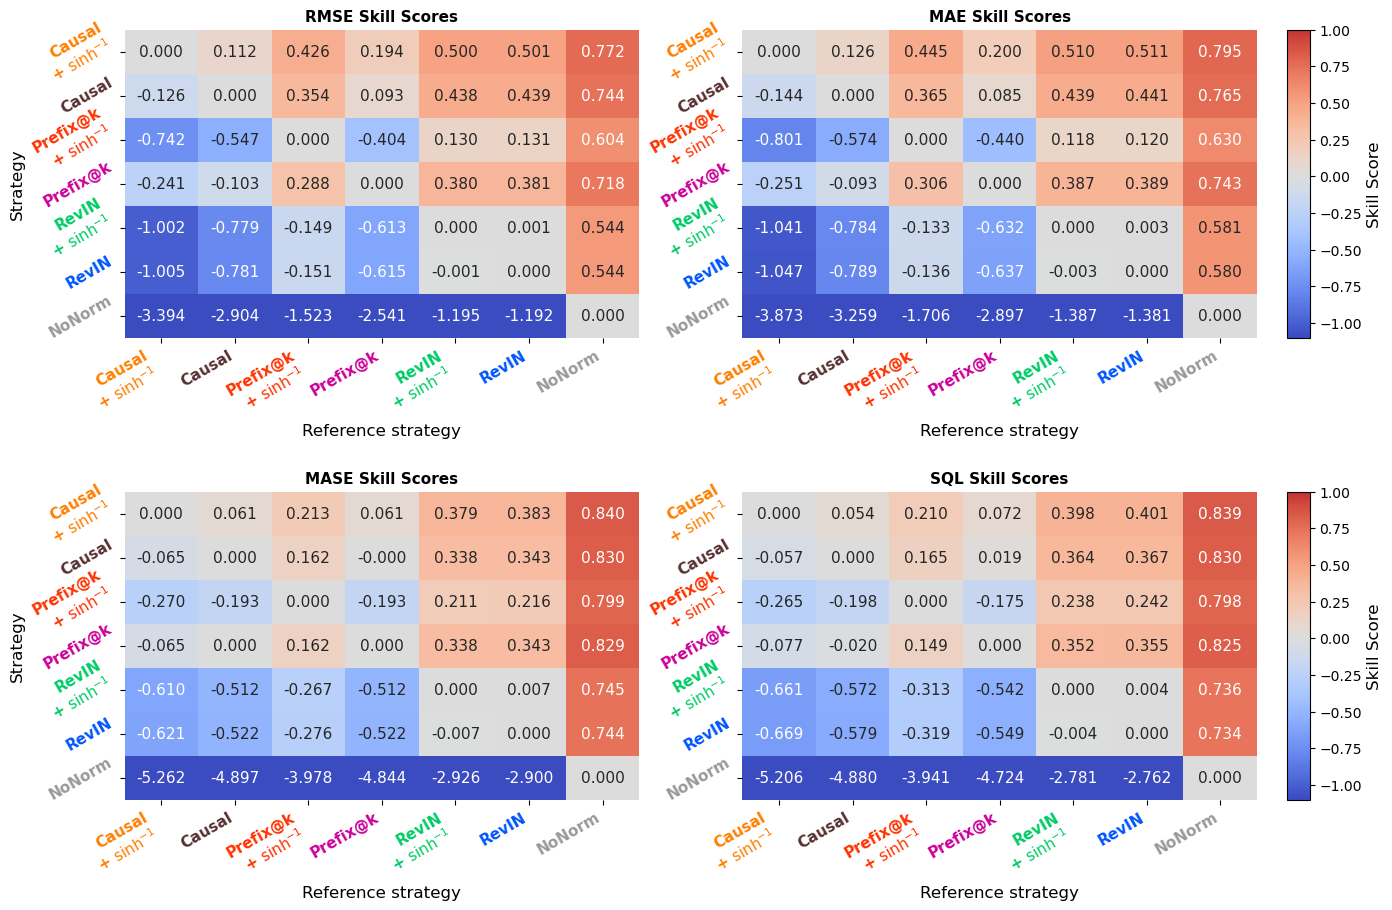

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

display_names = []
for m in models:
    label = model_name_to_show_label[m]
    if '+ $\sinh^{-1}$' in label:
        label = label.replace(' + $\sinh^{-1}$', '\n+ $\sinh^{-1}$')
    display_names.append(label)

metrics = [
    ('mse',  'RMSE Skill Scores'),
    ('mae',  'MAE Skill Scores'),
    ('mase', 'MASE Skill Scores'),
    ('sql',  'SQL Skill Scores'),
]

vmin, vmax = -1.1, 1

for idx, (metric, title) in enumerate(metrics):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    sns.heatmap(aggregated_skill_scores[metric], annot=True, fmt='.3f', cmap='coolwarm',
                xticklabels=display_names, yticklabels=display_names,
                center=0, ax=ax, cbar=False, vmin=vmin, vmax=vmax,
                annot_kws={'fontsize': 11})

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Reference strategy', fontsize=12)
    ax.set_ylabel('Strategy' if col == 0 else '', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')
    ax.tick_params(axis='both', labelsize=11)

    for label in ax.get_xticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')

fig.subplots_adjust(right=0.88, hspace=0.5)

# One colorbar per row, vertically centered on each row
for row in range(2):
    # Get the bounding boxes of the two axes in this row
    pos0 = axes[row, 0].get_position()
    pos1 = axes[row, 1].get_position()
    cbar_ax = fig.add_axes([0.90, pos0.y0, 0.015, pos0.y1 - pos0.y0])
    cbar = fig.colorbar(axes[row, 1].collections[0], cax=cbar_ax)
    cbar.set_label('Skill Score', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

if INCLUDE_NO_NORM:
    plt.savefig('figures/skill_score/skill_scores_nonorm.pdf', format='pdf', dpi=300, bbox_inches='tight')
else:
    plt.savefig('figures/skill_score/skill_scores.pdf', format='pdf', dpi=300, bbox_inches='tight')